In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [2]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


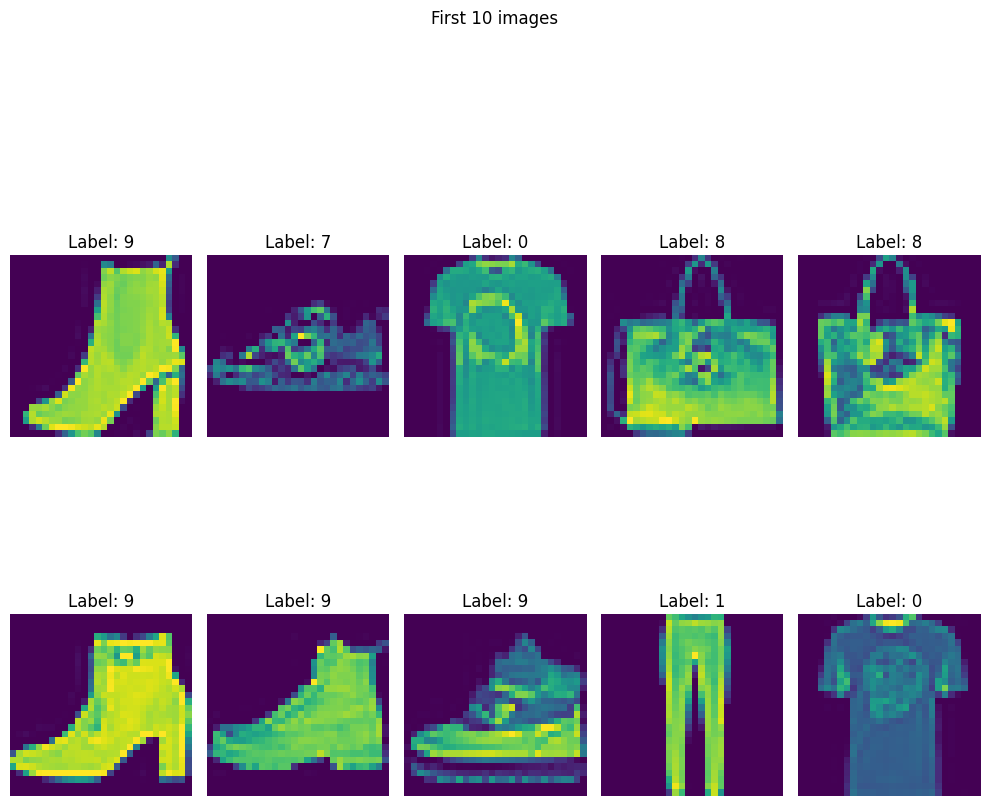

In [5]:
fig, axes = plt.subplots(2,5, figsize=(10,10))
fig.suptitle('First 10 images')

for i , ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i, 0]}")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [6]:
#train test split
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [7]:
x_tr, x_ts, y_tr, y_ts = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
#scaling
x_tr = x_tr / 255.0
y_ts = y_ts/ 255.0

In [9]:
x_tr

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]], shape=(4800, 784))

In [20]:
#create a dataset

class CustomDataset(Dataset):

    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float64)
        self.labels = torch.tensor(labels, dtype=torch.long)

    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        return self.features[index],self.labels[index]

In [21]:
tr_data = CustomDataset(x_tr, y_tr)

In [22]:
tr_data[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [23]:
ts_data = CustomDataset(x_ts, y_ts)

In [24]:
tr_loader = DataLoader(tr_data, batch_size=32, shuffle=True)
ts_loader = DataLoader(ts_data, batch_size=32, shuffle=False)

In [25]:
#building an ANN

class SimpleANN(nn.Module):

    def __init__(self, n_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.model(x)

In [28]:
epochs = 100
learning_rate = 0.1
model = SimpleANN(x_tr.shape[1])
lossfunc = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [29]:
len(tr_loader)

150

In [33]:
for epoch in range(epochs):
    total_loss = 0

    for batch_features, batch_labels in tr_loader:

        outs = model(batch_features.float())
        loss = lossfunc(outs, batch_labels)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss/len(tr_loader)
    print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')   



Epoch: 1 , Loss: 0.00572656016224452
Epoch: 2 , Loss: 0.01844977601392505
Epoch: 3 , Loss: 0.051602006035779295
Epoch: 4 , Loss: 0.09410605003863262
Epoch: 5 , Loss: 0.03090154256943303
Epoch: 6 , Loss: 0.041656753130761594
Epoch: 7 , Loss: 0.006107045654401493
Epoch: 8 , Loss: 0.004964710943944131
Epoch: 9 , Loss: 0.006045131479816821
Epoch: 10 , Loss: 0.010641962446388788
Epoch: 11 , Loss: 0.0034689959773095327
Epoch: 12 , Loss: 0.002454430748378703
Epoch: 13 , Loss: 0.001972120220598299
Epoch: 14 , Loss: 0.0018196045180472234
Epoch: 15 , Loss: 0.0016993629375550276
Epoch: 16 , Loss: 0.001479900810518302
Epoch: 17 , Loss: 0.001492506071808748
Epoch: 18 , Loss: 0.0014336229907833816
Epoch: 19 , Loss: 0.0012955076873186044
Epoch: 20 , Loss: 0.0012378140149909692
Epoch: 21 , Loss: 0.0012354764860113695
Epoch: 22 , Loss: 0.001124194968579104
Epoch: 23 , Loss: 0.0011220014084634992
Epoch: 24 , Loss: 0.0010409583504952026
Epoch: 25 , Loss: 0.0009642677835654468
Epoch: 26 , Loss: 0.00096651

In [34]:
# set model to eval mode
model.eval()

SimpleANN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [38]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in ts_loader:

    outputs = model(batch_features.float())

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)


0.11166666666666666


In [39]:
len(ts_loader)

38